# Credit Union Partnership Growth Strategy Analysis
### A Data-Driven Opportunity Scorecard — Applied to University Credit Union (UCU)

**Analyst:** Pranav Piedy | UCLA Anderson MSBA '26  
**Date:** March 2026  
**Data Sources:** IPEDS Fall Enrollment (EF), IPEDS Employees (EAP), NCUA 5300 Call Reports, U.S. Census Bureau

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(12,6),'font.family':'sans-serif',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})

C = {'navy':'#1B365D','teal':'#0891B2','gold':'#F59E0B','green':'#10B981',
     'red':'#EF4444','purple':'#8B5CF6','text':'#1E293B','muted':'#64748B'}

In [2]:
#CONFIG
DATA_DIR = 'D:/Pranav/UCLA/Internships/UCU/data/final_data/'   
VIS_DIR  = 'D:/Pranav/UCLA/Internships/UCU//visuals/' 
os.makedirs(VIS_DIR, exist_ok=True)

# UCU Partner Schools — IPEDS UNITIDs
PARTNERS = {
    110662: {'name':'UCLA','state':'CA','type':'Public R1','joined':1951,'conf':'Founding'},
    121150: {'name':'Pepperdine University','state':'CA','type':'Private','joined':2010,'conf':'WCC'},
    117946: {'name':'Loyola Marymount University','state':'CA','type':'Private','joined':2012,'conf':'WCC'},
    122931: {'name':'Santa Clara University','state':'CA','type':'Private','joined':2015,'conf':'WCC'},
    123554: {'name':"Saint Mary's College of CA",'state':'CA','type':'Private','joined':2024,'conf':'WCC'},
    110653: {'name':'UC Irvine','state':'CA','type':'Public R1','joined':2018,'conf':'UC System'},
    110644: {'name':'UC Davis','state':'CA','type':'Public R1','joined':2019,'conf':'UC System'},
    110680: {'name':'UC San Diego','state':'CA','type':'Public R1','joined':2020,'conf':'UC System'},
    139755: {'name':'Georgia Tech','state':'GA','type':'Public R1','joined':2021,'conf':'Out-of-State'},
    228769: {'name':'UT Arlington','state':'TX','type':'Public R1','joined':2024,'conf':'Out-of-State'},
    222178: {'name':'Abilene Christian University','state':'TX','type':'Private','joined':2025,'conf':'WAC'},
    119173: {'name':"Mount Saint Mary's University",'state':'CA','type':'Private','joined':2016,'conf':'LA Local'},
    111920: {'name':'Chabot College','state':'CA','type':'Community College','joined':2014,'conf':'CC'},
    366401: {'name':'Las Positas College','state':'CA','type':'Community College','joined':2014,'conf':'CC'},
}
PARTNER_IDS = list(PARTNERS.keys())
YEARS = list(range(2019, 2025))

# Census data (median household income by campus metro)
CENSUS = {
    'UCLA':82000,'Pepperdine University':82000,'Loyola Marymount University':82000,
    "Mount Saint Mary's University":82000,'Santa Clara University':133000,
    "Saint Mary's College of CA":120000,'UC Irvine':82000,'UC Davis':78000,
    'UC San Diego':85000,'Georgia Tech':75000,'UT Arlington':72000,
    'Abilene Christian University':52000,'Chabot College':120000,'Las Positas College':120000,
}
print(f'Config: {len(PARTNERS)} schools, {YEARS[0]}-{YEARS[-1]}')

Config: 14 schools, 2019-2024


## 2. Data Ingestion & Cleaning

**Source files:**
- `ef{YEAR}a.csv` / `ef{YEAR}a_rv.csv` — Fall Enrollment (all US institutions)
- `eap{YEAR}.csv` / `eap{YEAR}_rv.csv` — Employees by Assigned Position (all US institutions)

**Filters applied:**
- Enrollment: `EFALEVEL == 1` → All students total
- Employees: `EAPCAT == 10000` → All staff total
- Both filtered to UCU partner UNITIDs only

In [3]:
# ============================================================
# LOAD FALL ENROLLMENT (2019-2024)
# File convention: 2024=ef2024a.csv, 2019-2023=ef{year}a_rv.csv
# ============================================================
enroll_frames = []
for year in YEARS:
    fname = f'{DATA_DIR}ef{year}a.csv' if year == 2024 else f'{DATA_DIR}ef{year}a_rv.csv'
    try:
        df = pd.read_csv(fname, encoding='latin-1')
        df = df[(df['EFALEVEL']==1) & (df['UNITID'].isin(PARTNER_IDS))][['UNITID','EFTOTLT','EFTOTLM','EFTOTLW']].copy()
        for c in ['EFTOTLT','EFTOTLM','EFTOTLW']: df[c] = pd.to_numeric(df[c], errors='coerce')
        df['year'] = year
        enroll_frames.append(df)
        print(f'  {year}: {len(df)} schools | {os.path.basename(fname)}')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND - {fname}')

enrollment = pd.concat(enroll_frames, ignore_index=True)
enrollment.rename(columns={'UNITID':'unitid','EFTOTLT':'total_enrollment',
                           'EFTOTLM':'enrollment_men','EFTOTLW':'enrollment_women'}, inplace=True)
enrollment['institution_name'] = enrollment['unitid'].map({k:v['name'] for k,v in PARTNERS.items()})
print(f'\nEnrollment: {len(enrollment)} rows ({enrollment["unitid"].nunique()} schools x {enrollment["year"].nunique()} years)')

  2019: 14 schools | ef2019a_rv.csv
  2020: 14 schools | ef2020a_rv.csv
  2021: 14 schools | ef2021a_rv.csv
  2022: 14 schools | ef2022a_rv.csv
  2023: 14 schools | ef2023a_rv.csv
  2024: 14 schools | ef2024a.csv

Enrollment: 84 rows (14 schools x 6 years)


In [4]:
# ============================================================
# LOAD EMPLOYEE DATA (2019-2024)
# File convention: 2024=eap2024.csv, 2019-2023=eap{year}_rv.csv
# Filter: EAPCAT==10000 ("All staff" top-level total)
# ============================================================
emp_frames = []
for year in YEARS:
    fname = f'{DATA_DIR}eap{year}.csv' if year == 2024 else f'{DATA_DIR}eap{year}_rv.csv'
    try:
        df = pd.read_csv(fname, encoding='latin-1')
        df = df[(df['EAPCAT']==10000) & (df['UNITID'].isin(PARTNER_IDS))][['UNITID','EAPTOT','EAPFT','EAPPT']].copy()
        for c in ['EAPTOT','EAPFT','EAPPT']: df[c] = pd.to_numeric(df[c], errors='coerce')
        df['year'] = year
        emp_frames.append(df)
        print(f'  {year}: {len(df)} schools | {os.path.basename(fname)}')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND - {fname}')

employees = pd.concat(emp_frames, ignore_index=True)
employees.rename(columns={'UNITID':'unitid','EAPTOT':'total_employees',
                          'EAPFT':'ft_employees','EAPPT':'pt_employees'}, inplace=True)
employees['institution_name'] = employees['unitid'].map({k:v['name'] for k,v in PARTNERS.items()})
print(f'\nEmployees: {len(employees)} rows ({employees["unitid"].nunique()} schools x {employees["year"].nunique()} years)')

  2019: 14 schools | eap2019_rv.csv
  2020: 14 schools | eap2020_rv.csv
  2021: 14 schools | eap2021_rv.csv
  2022: 14 schools | eap2022_rv.csv
  2023: 14 schools | eap2023_rv.csv
  2024: 14 schools | eap2024.csv

Employees: 84 rows (14 schools x 6 years)


In [5]:
# ============================================================
# LOAD NCUA 5300 CALL REPORT DATA (Q4 2019-2024)
# Source: https://ncua.gov/analysis/credit-union-corporate-call-report-data
# CU Number: 64171 (University Credit Union)
# Files: q4_{year}.xlsx — each has 3 sheets: Glossary, ProfileGenInfo, Total Accounts
# ============================================================
import openpyxl

# Key account codes from the NCUA 5300 Call Report glossary
NCUA_FIELDS = {
    '010': 'total_assets',
    '025B': 'total_loans',
    '083': 'members',
    'SH0013': 'total_shares',
    '661A': 'net_income',
    '997': 'net_worth',
}

ncua_rows = []
for year in YEARS:
    fname = f'{DATA_DIR}q4_{year}.xlsx'
    try:
        wb = openpyxl.load_workbook(fname)
        ws = wb['Total Accounts']
        headers, data = None, None
        for i, row in enumerate(ws.iter_rows(values_only=True)):
            if i == 0: headers = [str(h) for h in row]
            if i == 1: data = row
        
        record = {'year': year, 'cu_number': data[0]}
        for j, (h, v) in enumerate(zip(headers, data)):
            if h in NCUA_FIELDS:
                record[NCUA_FIELDS[h]] = v
        ncua_rows.append(record)
        print(f'  {year}: Members={record.get("members","?"):>7,} | Assets=${record.get("total_assets",0)/1e6:>7,.1f}M | Loans=${record.get("total_loans",0)/1e6:>7,.1f}M')
    except FileNotFoundError:
        print(f'  {year}: NOT FOUND - {fname}')

ncua = pd.DataFrame(ncua_rows)

# Calculate YoY growth rates
ncua = ncua.sort_values('year')
ncua['member_growth_pct'] = ncua['members'].pct_change() * 100
ncua['asset_growth_pct'] = ncua['total_assets'].pct_change() * 100
ncua['loan_growth_pct'] = ncua['total_loans'].pct_change() * 100

print(f'\nNCUA: {len(ncua)} annual snapshots (Q4 {ncua["year"].min()}-{ncua["year"].max()})')
print(f'Member growth: {ncua.iloc[0]["members"]:,.0f} → {ncua.iloc[-1]["members"]:,.0f} ({(ncua.iloc[-1]["members"]/ncua.iloc[0]["members"]-1)*100:.1f}% total)')
print(f'Asset growth:  ${ncua.iloc[0]["total_assets"]/1e6:,.0f}M → ${ncua.iloc[-1]["total_assets"]/1e6:,.0f}M ({(ncua.iloc[-1]["total_assets"]/ncua.iloc[0]["total_assets"]-1)*100:.1f}% total)')

  2019: Members= 41,066 | Assets=$  739.9M | Loans=$  406.4M
  2020: Members= 41,969 | Assets=$  872.6M | Loans=$  510.9M
  2021: Members= 49,397 | Assets=$1,047.1M | Loans=$  659.7M
  2022: Members= 52,065 | Assets=$1,226.0M | Loans=$1,021.1M
  2023: Members= 52,100 | Assets=$1,165.7M | Loans=$1,023.6M
  2024: Members= 56,372 | Assets=$1,135.9M | Loans=$  948.9M

NCUA: 6 annual snapshots (Q4 2019-2024)
Member growth: 41,066 → 56,372 (37.3% total)
Asset growth:  $740M → $1,136M (53.5% total)


In [6]:
# ============================================================
# MERGE INTO MASTER DATASET
# ============================================================
master = enrollment.merge(employees[['unitid','year','total_employees','ft_employees','pt_employees']],
                          on=['unitid','year'], how='left')

# Add partnership metadata
for uid, info in PARTNERS.items():
    m = master['unitid']==uid
    for k in ['state','type','joined','conf']:
        col = {'type':'institution_type','joined':'year_joined_ucu','conf':'conference'}.get(k,k)
        master.loc[m, col] = info[k]

# Add census income
master['median_income'] = master['institution_name'].map(CENSUS)

# Derived columns
master['total_addressable_pop'] = master['total_enrollment'] + master['total_employees'].fillna(0)
master['partnership_age'] = (master['year'] - master['year_joined_ucu']).clip(lower=0)
master['pct_women'] = (master['enrollment_women'] / master['total_enrollment'] * 100).round(1)
master['ft_pct'] = (master['ft_employees'] / master['total_employees'] * 100).round(1)
master = master.sort_values(['unitid','year'])
master['enrollment_yoy'] = master.groupby('unitid')['total_enrollment'].pct_change() * 100

print(f'Master: {len(master)} rows x {len(master.columns)} cols')
print(f'Nulls in key columns:\n{master[["total_enrollment","total_employees"]].isnull().sum()}')

Master: 84 rows x 19 cols
Nulls in key columns:
total_enrollment    0
total_employees     0
dtype: int64


## 3. Validation & Summary

In [7]:
# Validate UCLA 2024
ucla = master[(master['institution_name']=='UCLA') & (master['year']==2024)]
print('=== UCLA 2024 VALIDATION ===')
print(f'  Enrollment: {ucla["total_enrollment"].values[0]:,.0f}')
print(f'  Employees:  {ucla["total_employees"].values[0]:,.0f}')
print(f'  TAM:        {ucla["total_addressable_pop"].values[0]:,.0f}')

# All schools 2024
latest = master[master['year']==2024].sort_values('total_addressable_pop', ascending=False)
total_tam = latest['total_addressable_pop'].sum()
print(f'\n=== ALL PARTNERS 2024 ===')
for _, r in latest.iterrows():
    print(f'  {r["institution_name"]:35s} Enroll: {r["total_enrollment"]:>7,.0f}  Staff: {r["total_employees"]:>7,.0f}  TAM: {r["total_addressable_pop"]:>8,.0f}')
print(f'\n  TOTAL ADDRESSABLE MARKET: {total_tam:,.0f}')

=== UCLA 2024 VALIDATION ===
  Enrollment: 47,335
  Employees:  30,136
  TAM:        77,471

=== ALL PARTNERS 2024 ===
  UCLA                                Enroll:  47,335  Staff:  30,136  TAM:   77,471
  Georgia Tech                        Enroll:  53,363  Staff:  10,954  TAM:   64,317
  UC San Diego                        Enroll:  44,256  Staff:  19,504  TAM:   63,760
  UC Davis                            Enroll:  40,065  Staff:  15,029  TAM:   55,094
  UT Arlington                        Enroll:  44,956  Staff:   4,658  TAM:   49,614
  UC Irvine                           Enroll:  37,297  Staff:  10,206  TAM:   47,503
  Chabot College                      Enroll:  12,842  Staff:     764  TAM:   13,606
  Loyola Marymount University         Enroll:  10,179  Staff:   2,639  TAM:   12,818
  Santa Clara University              Enroll:   9,728  Staff:   2,103  TAM:   11,831
  Pepperdine University               Enroll:   8,976  Staff:   2,165  TAM:   11,141
  Las Positas College          

## 4. Exploratory Analysis

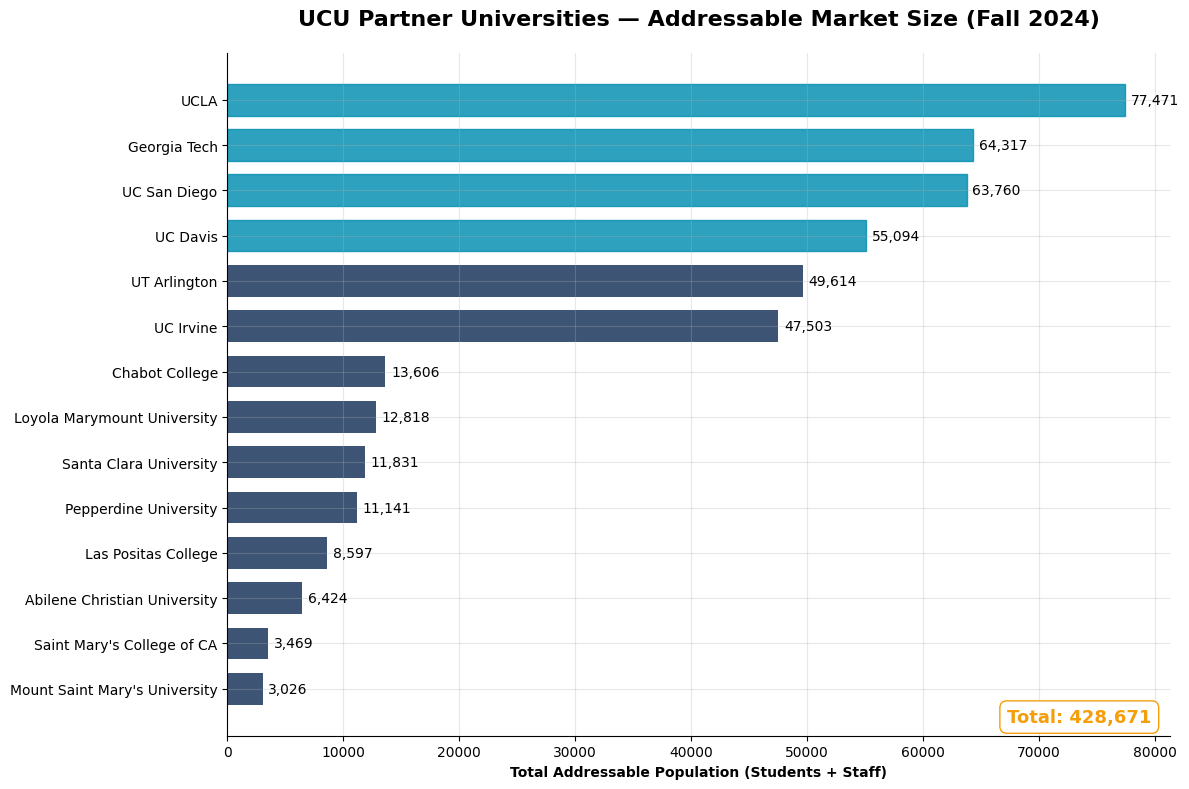

In [8]:
# CHART 1: Addressable Market (2024)
ls = latest.sort_values('total_addressable_pop', ascending=True)
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(ls['institution_name'], ls['total_addressable_pop'], color=C['navy'], alpha=0.85, height=0.7)
q75 = ls['total_addressable_pop'].quantile(0.75)
for bar in bars:
    if bar.get_width() > q75: bar.set_color(C['teal'])
    ax.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2, f'{bar.get_width():,.0f}', va='center', fontsize=10)
ax.set_xlabel('Total Addressable Population (Students + Staff)', fontweight='bold')
ax.set_title('UCU Partner Universities — Addressable Market Size (Fall 2024)', fontweight='bold', fontsize=16, pad=20)
ax.annotate(f'Total: {total_tam:,.0f}', xy=(0.98,0.02), xycoords='axes fraction', ha='right', fontsize=13,
            fontweight='bold', color=C['gold'], bbox=dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor=C['gold']))
plt.tight_layout(); plt.savefig(f'{VIS_DIR}01_addressable_market.png', dpi=150, bbox_inches='tight'); plt.show()

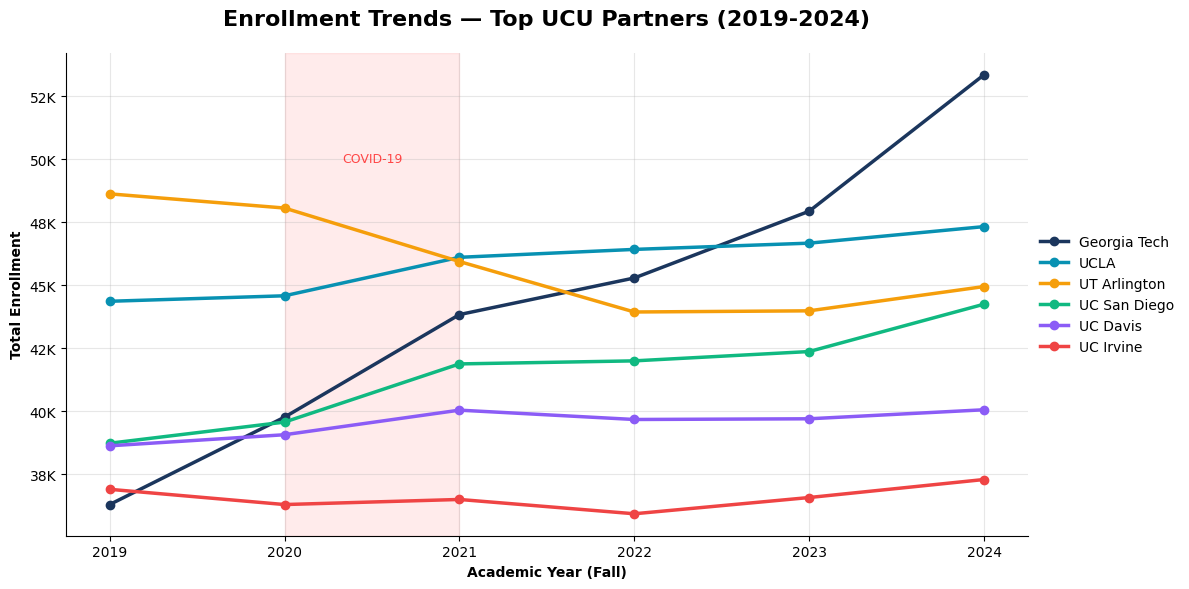

In [9]:
# CHART 2: Enrollment Trends (2019-2024)
top6 = latest.nlargest(6,'total_enrollment')['institution_name'].values
cl = [C['navy'],C['teal'],C['gold'],C['green'],C['purple'],C['red']]
fig, ax = plt.subplots(figsize=(12,6))
for i, s in enumerate(top6):
    sd = master[master['institution_name']==s].sort_values('year')
    ax.plot(sd['year'], sd['total_enrollment'], marker='o', linewidth=2.5, label=s, color=cl[i], markersize=6)
ax.set_xlabel('Academic Year (Fall)', fontweight='bold')
ax.set_ylabel('Total Enrollment', fontweight='bold')
ax.set_title('Enrollment Trends — Top UCU Partners (2019-2024)', fontweight='bold', fontsize=16, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False)
ax.axvspan(2020,2021, alpha=0.08, color='red')
ax.annotate('COVID-19', xy=(2020.5, ax.get_ylim()[1]*0.92), ha='center', fontsize=9, color='red', alpha=0.7)
plt.tight_layout(); plt.savefig(f'{VIS_DIR}02_enrollment_trends.png', dpi=150, bbox_inches='tight'); plt.show()

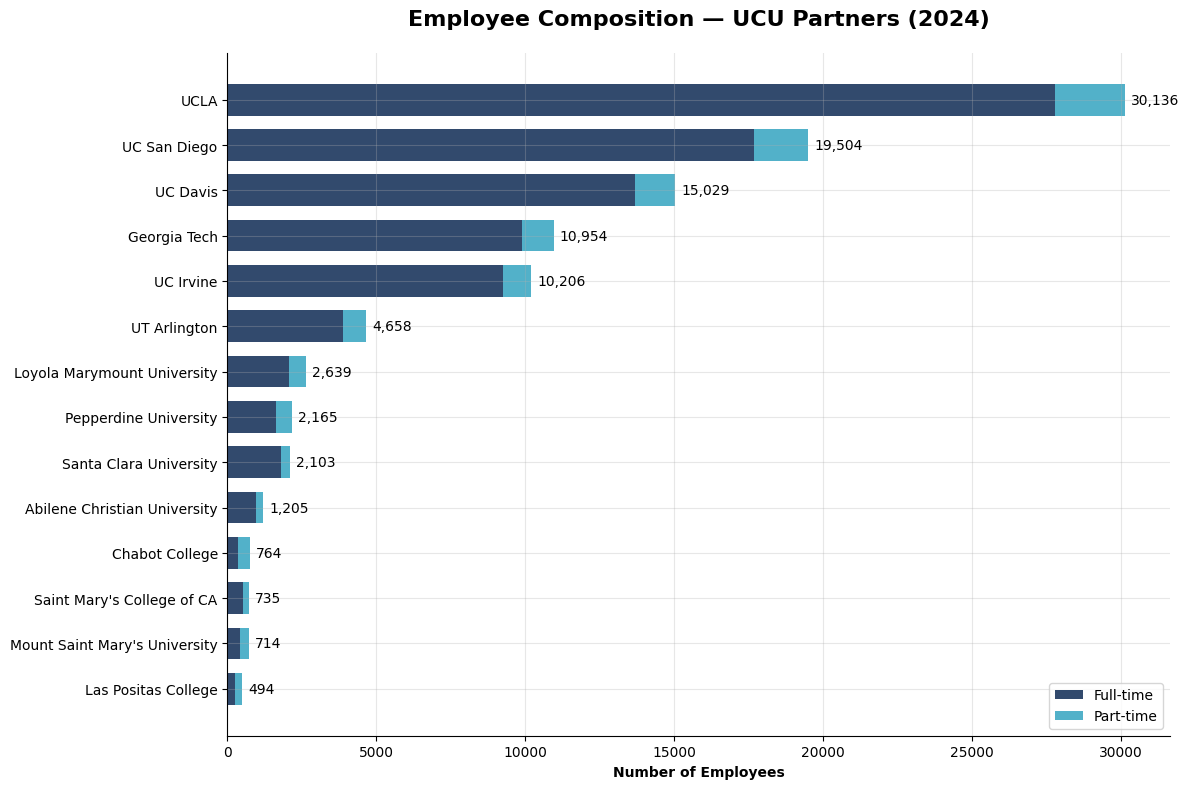

In [10]:
# CHART 3: Employee Composition FT vs PT (2024)
e24 = latest[['institution_name','ft_employees','pt_employees','total_employees']].dropna().sort_values('total_employees', ascending=True)
fig, ax = plt.subplots(figsize=(12,8))
ax.barh(e24['institution_name'], e24['ft_employees'], color=C['navy'], alpha=0.9, label='Full-time', height=0.7)
ax.barh(e24['institution_name'], e24['pt_employees'], left=e24['ft_employees'], color=C['teal'], alpha=0.7, label='Part-time', height=0.7)
for i, (_,row) in enumerate(e24.iterrows()):
    ax.text(row['total_employees']+200, i, f'{row["total_employees"]:,.0f}', va='center', fontsize=10)
ax.set_xlabel('Number of Employees', fontweight='bold')
ax.set_title('Employee Composition — UCU Partners (2024)', fontweight='bold', fontsize=16, pad=20)
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}03_employee_composition.png', dpi=150, bbox_inches='tight'); plt.show()

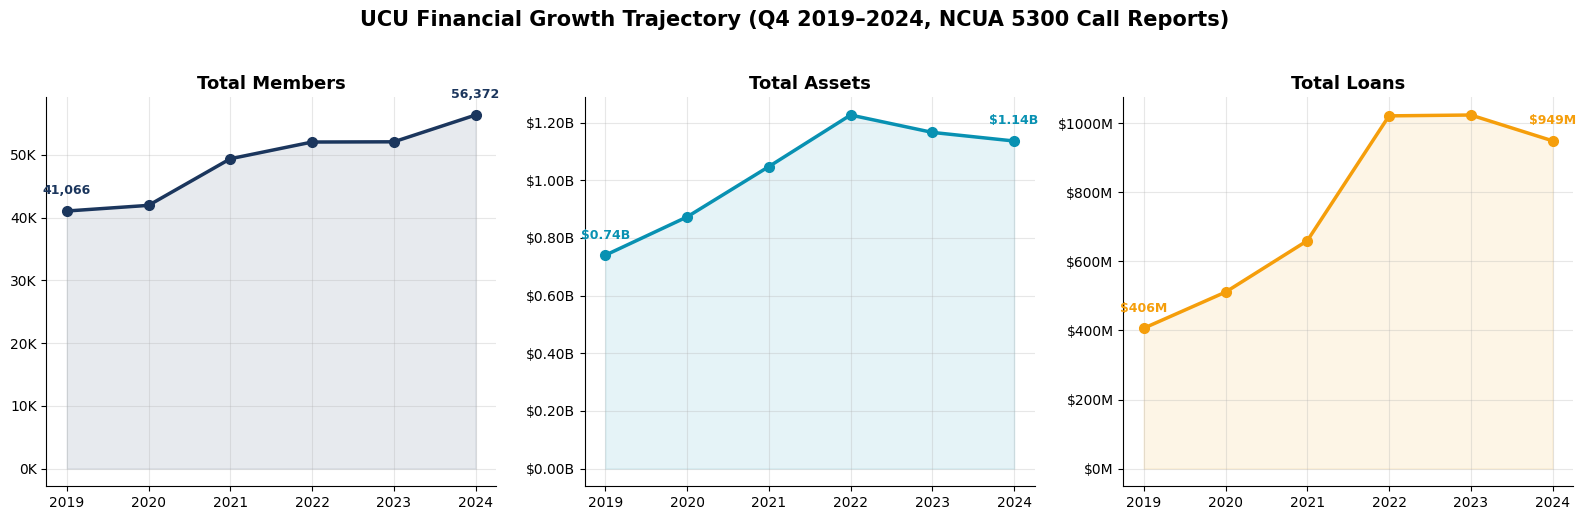

5-Year Growth Summary:
  Members: 41,066 → 56,372 (+37.3%)
  Assets:  $740M → $1,136M (+53.5%)
  Loans:   $406M → $949M (+133.5%)


In [11]:
# ============================================================
# CHART 4: UCU FINANCIAL GROWTH (NCUA DATA, 2019-2024)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('members', 'Total Members', C['navy'], lambda x,_: f'{x/1000:.0f}K'),
    ('total_assets', 'Total Assets', C['teal'], lambda x,_: f'${x/1e9:.2f}B'),
    ('total_loans', 'Total Loans', C['gold'], lambda x,_: f'${x/1e6:.0f}M'),
]

for idx, (col, title, color, fmt) in enumerate(metrics):
    ax = axes[idx]
    ax.plot(ncua['year'], ncua[col], color=color, linewidth=2.5, marker='o', markersize=7)
    ax.fill_between(ncua['year'], ncua[col], alpha=0.1, color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.set_xticks(ncua['year'])
    # Annotate first and last
    for i in [0, len(ncua)-1]:
        r = ncua.iloc[i]
        val = r[col]
        if col == 'members': label = f'{val:,.0f}'
        elif col == 'total_assets': label = f'${val/1e9:.2f}B'
        else: label = f'${val/1e6:.0f}M'
        ax.annotate(label, (r['year'], val), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold', color=color)

fig.suptitle('UCU Financial Growth Trajectory (Q4 2019–2024, NCUA 5300 Call Reports)',
             fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig(f'{VIS_DIR}04_ucu_financials.png', dpi=150, bbox_inches='tight')
plt.show()

# Growth summary
print(f'5-Year Growth Summary:')
print(f'  Members: {ncua.iloc[0]["members"]:,.0f} → {ncua.iloc[-1]["members"]:,.0f} (+{(ncua.iloc[-1]["members"]/ncua.iloc[0]["members"]-1)*100:.1f}%)')
print(f'  Assets:  ${ncua.iloc[0]["total_assets"]/1e6:,.0f}M → ${ncua.iloc[-1]["total_assets"]/1e6:,.0f}M (+{(ncua.iloc[-1]["total_assets"]/ncua.iloc[0]["total_assets"]-1)*100:.1f}%)')
print(f'  Loans:   ${ncua.iloc[0]["total_loans"]/1e6:,.0f}M → ${ncua.iloc[-1]["total_loans"]/1e6:,.0f}M (+{(ncua.iloc[-1]["total_loans"]/ncua.iloc[0]["total_loans"]-1)*100:.1f}%)')

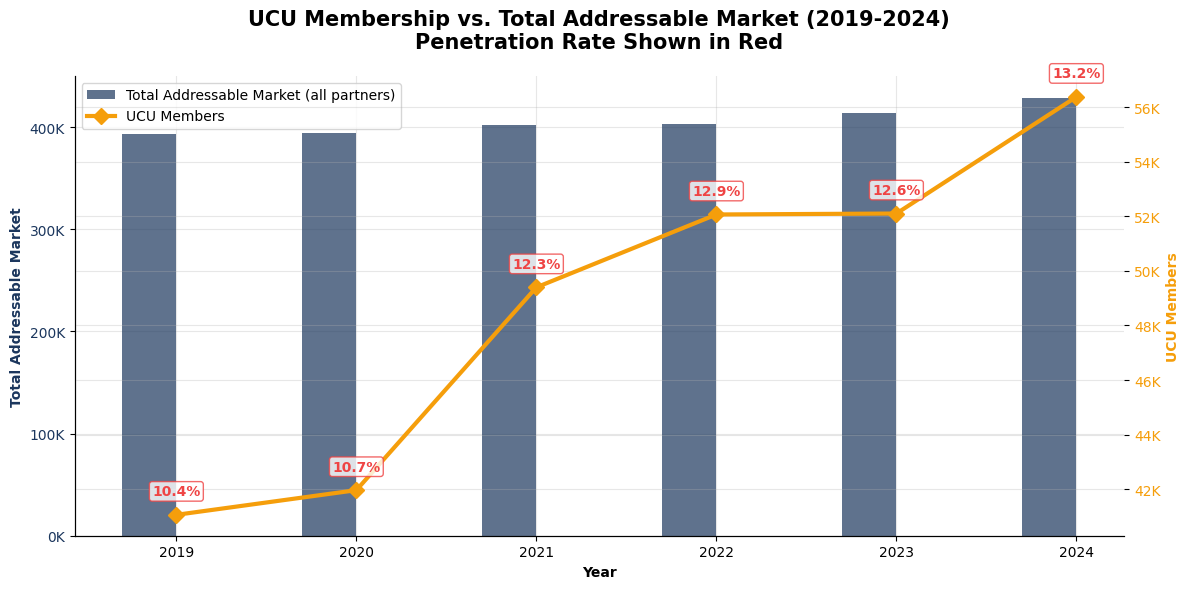


=== PENETRATION ANALYSIS ===
  2019: TAM= 393,632 | Members=41,066 | Penetration= 10.4%
  2020: TAM= 394,096 | Members=41,969 | Penetration= 10.7%
  2021: TAM= 402,075 | Members=49,397 | Penetration= 12.3%
  2022: TAM= 402,954 | Members=52,065 | Penetration= 12.9%
  2023: TAM= 413,968 | Members=52,100 | Penetration= 12.6%
  2024: TAM= 428,671 | Members=56,372 | Penetration= 13.2%


In [12]:
# ============================================================
# CHART 5: MEMBERSHIP vs TAM GROWTH (Dual-Axis)
# This is the killer chart — shows UCU membership growth
# alongside partner school population growth
# ============================================================
# Aggregate total enrollment + staff per year across all partners
yearly_tam = master.groupby('year')['total_addressable_pop'].sum().reset_index()
yearly_tam.columns = ['year', 'total_tam']

# Merge with NCUA
comparison = yearly_tam.merge(ncua[['year','members']], on='year', how='inner')
comparison['penetration_pct'] = (comparison['members'] / comparison['total_tam'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(12, 6))

# TAM on left axis
ax1.bar(comparison['year'] - 0.15, comparison['total_tam'], width=0.3, color=C['navy'],
        alpha=0.7, label='Total Addressable Market (all partners)', zorder=2)
ax1.set_ylabel('Total Addressable Market', fontweight='bold', color=C['navy'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax1.tick_params(axis='y', labelcolor=C['navy'])

# Members on right axis
ax2 = ax1.twinx()
ax2.plot(comparison['year'], comparison['members'], color=C['gold'], linewidth=3,
         marker='D', markersize=8, label='UCU Members', zorder=3)
ax2.set_ylabel('UCU Members', fontweight='bold', color=C['gold'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax2.tick_params(axis='y', labelcolor=C['gold'])

# Penetration labels on line
for _, r in comparison.iterrows():
    ax2.annotate(f'{r["penetration_pct"]:.1f}%', (r['year'], r['members']),
                 textcoords='offset points', xytext=(0, 14), ha='center',
                 fontsize=10, fontweight='bold', color=C['red'],
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=C['red'], alpha=0.8))

ax1.set_xlabel('Year', fontweight='bold')
ax1.set_title('UCU Membership vs. Total Addressable Market (2019-2024)\nPenetration Rate Shown in Red',
              fontweight='bold', fontsize=15, pad=20)
ax1.set_xticks(comparison['year'])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig(f'{VIS_DIR}05_membership_vs_tam.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== PENETRATION ANALYSIS ===')
for _, r in comparison.iterrows():
    print(f'  {int(r["year"])}: TAM={r["total_tam"]:>8,.0f} | Members={r["members"]:>6,.0f} | Penetration={r["penetration_pct"]:>5.1f}%')

## 5. Partnership Opportunity Scorecard

In [13]:
# BUILD SCORECARD
sc = latest[['institution_name','unitid','total_addressable_pop','total_enrollment','total_employees',
             'ft_employees','pt_employees','enrollment_yoy','median_income','year_joined_ucu',
             'partnership_age','conference','institution_type','state','pct_women']].copy()

def norm(s):
    r = s.max()-s.min()
    return pd.Series(50, index=s.index) if r==0 else ((s-s.min())/r*100).fillna(0)

sc['size_score']      = norm(sc['total_addressable_pop'])
sc['growth_score']    = norm(sc['enrollment_yoy'].fillna(0))
sc['need_score']      = norm(sc['median_income'].max() - sc['median_income'])
sc['freshness_score'] = norm(sc['partnership_age'].max() - sc['partnership_age'])

sc['opportunity_score'] = sc['size_score']*0.4 + sc['growth_score']*0.2 + sc['need_score']*0.2 + sc['freshness_score']*0.2
sc = sc.sort_values('opportunity_score', ascending=False)
sc['tier'] = pd.cut(sc['opportunity_score'], bins=[-1,33,66,101], labels=['Tier 3: Maintain','Tier 2: Grow','Tier 1: Prioritize'])

print('=== OPPORTUNITY SCORECARD ===')
for _, r in sc.iterrows():
    print(f'  {r["institution_name"]:35s} Score:{r["opportunity_score"]:5.1f}  TAM:{r["total_addressable_pop"]:>8,.0f}  [{r["tier"]}]')

=== OPPORTUNITY SCORECARD ===
  Georgia Tech                        Score: 86.4  TAM:  64,317  [Tier 1: Prioritize]
  UC San Diego                        Score: 75.4  TAM:  63,760  [Tier 1: Prioritize]
  UT Arlington                        Score: 69.5  TAM:  49,614  [Tier 1: Prioritize]
  UC Davis                            Score: 68.1  TAM:  55,094  [Tier 1: Prioritize]
  UC Irvine                           Score: 64.0  TAM:  47,503  [Tier 2: Grow]
  UCLA                                Score: 61.1  TAM:  77,471  [Tier 2: Grow]
  Abilene Christian University        Score: 51.1  TAM:   6,424  [Tier 2: Grow]
  Loyola Marymount University         Score: 40.6  TAM:  12,818  [Tier 2: Grow]
  Las Positas College                 Score: 40.6  TAM:   8,597  [Tier 2: Grow]
  Chabot College                      Score: 39.0  TAM:  13,606  [Tier 2: Grow]
  Mount Saint Mary's University       Score: 37.5  TAM:   3,026  [Tier 2: Grow]
  Santa Clara University              Score: 34.0  TAM:  11,831  [

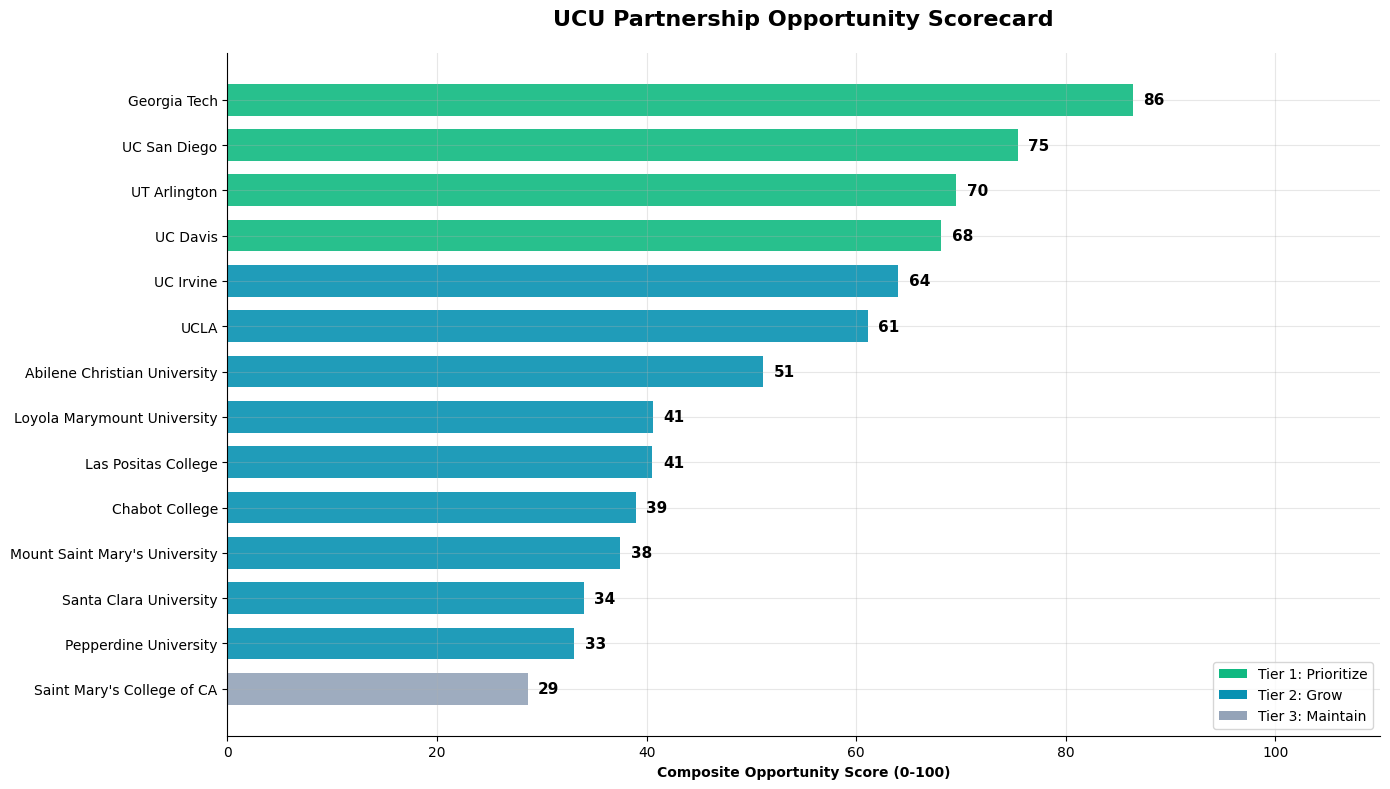

In [14]:
# CHART 6: Scorecard
ss = sc.sort_values('opportunity_score', ascending=True)
tc = {'Tier 1: Prioritize':C['green'],'Tier 2: Grow':C['teal'],'Tier 3: Maintain':'#94A3B8'}
bc = [tc.get(str(t),'#94A3B8') for t in ss['tier']]
fig, ax = plt.subplots(figsize=(14,8))
bars = ax.barh(ss['institution_name'], ss['opportunity_score'], color=bc, height=0.7, alpha=0.9)
for bar, s in zip(bars, ss['opportunity_score']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'{s:.0f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Composite Opportunity Score (0-100)', fontweight='bold')
ax.set_title('UCU Partnership Opportunity Scorecard', fontweight='bold', fontsize=16, pad=20)
ax.set_xlim(0,110)
ax.legend(handles=[Patch(facecolor=C['green'],label='Tier 1: Prioritize'),
                   Patch(facecolor=C['teal'],label='Tier 2: Grow'),
                   Patch(facecolor='#94A3B8',label='Tier 3: Maintain')], loc='lower right')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}06_opportunity_scorecard.png', dpi=150, bbox_inches='tight'); plt.show()

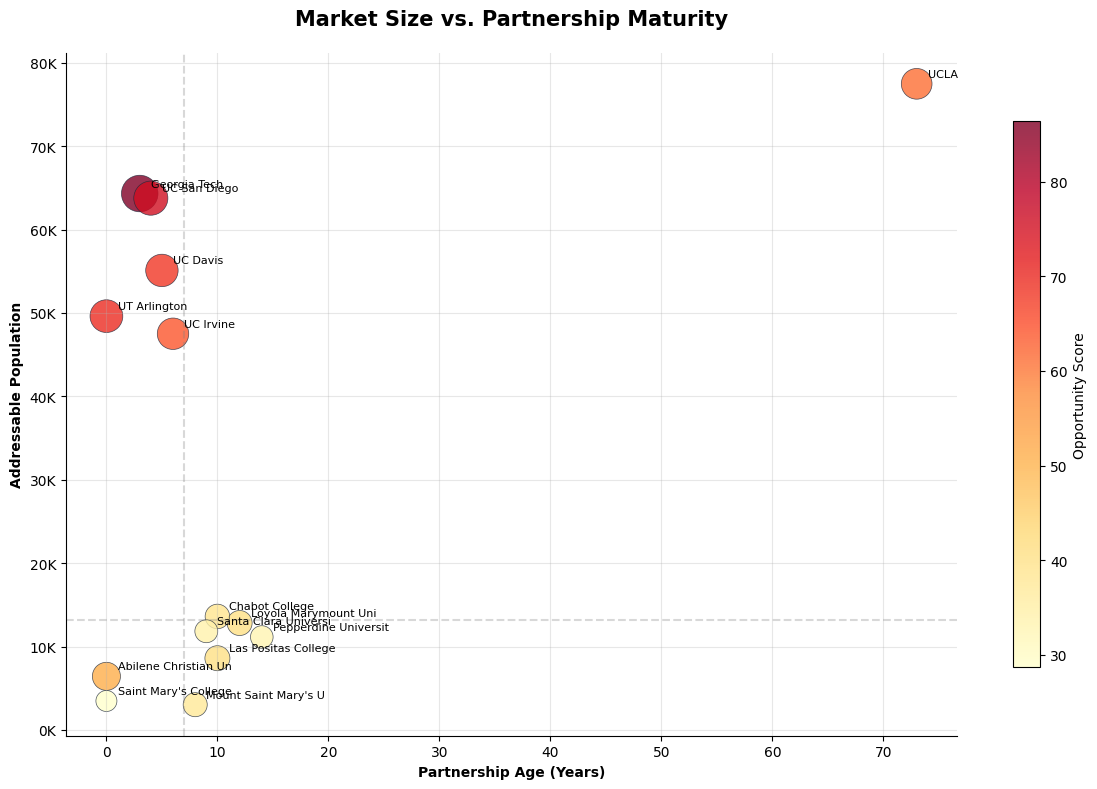

In [15]:
# CHART 7: Scatter — Market Size vs Partnership Age
fig, ax = plt.subplots(figsize=(12,8))
scat = ax.scatter(sc['partnership_age'], sc['total_addressable_pop'], s=sc['opportunity_score']*8,
                  c=sc['opportunity_score'], cmap='YlOrRd', alpha=0.8, edgecolors=C['text'], linewidths=0.5)
for _, r in sc.iterrows():
    ax.annotate(r['institution_name'][:20], (r['partnership_age'],r['total_addressable_pop']),
                textcoords='offset points', xytext=(8,5), fontsize=8)
ax.set_xlabel('Partnership Age (Years)', fontweight='bold')
ax.set_ylabel('Addressable Population', fontweight='bold')
ax.set_title('Market Size vs. Partnership Maturity', fontweight='bold', fontsize=15, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.axhline(y=sc['total_addressable_pop'].median(), color='gray', ls='--', alpha=0.3)
ax.axvline(x=sc['partnership_age'].median(), color='gray', ls='--', alpha=0.3)
plt.colorbar(scat, ax=ax, shrink=0.8, label='Opportunity Score')
plt.tight_layout(); plt.savefig(f'{VIS_DIR}07_scatter_opportunity.png', dpi=150, bbox_inches='tight'); plt.show()

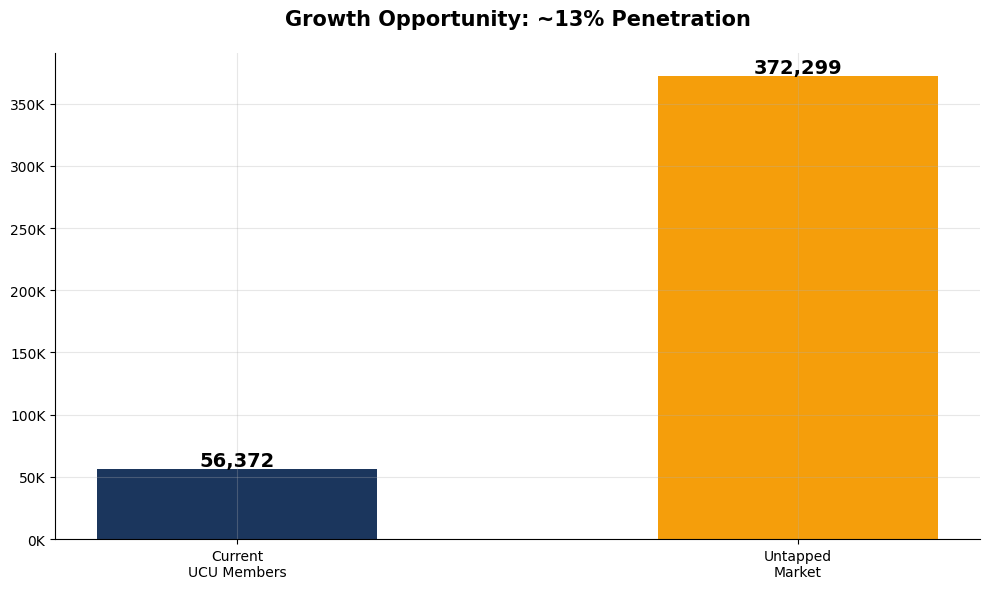

In [16]:
# CHART 8: Penetration Gap
ucu_members = int(ncua[ncua['year']==2024]['members'].values[0])  # Real NCUA figure
fig, ax = plt.subplots(figsize=(10,6))
vals = [ucu_members, total_tam - ucu_members]
bars = ax.bar(['Current\nUCU Members','Untapped\nMarket'], vals, color=[C['navy'],C['gold']], width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000, f'{val:,.0f}', ha='center', fontweight='bold', fontsize=14)
pen = ucu_members/total_tam*100
ax.set_title(f'Growth Opportunity: ~{pen:.0f}% Penetration', fontweight='bold', fontsize=15, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
plt.tight_layout(); plt.savefig(f'{VIS_DIR}08_penetration_gap.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. Strategic Summary

In [17]:
print('='*70)
for tn in ['Tier 1: Prioritize','Tier 2: Grow','Tier 3: Maintain']:
    td = sc[sc['tier']==tn]
    e = {'Tier 1: Prioritize':'\U0001f7e2','Tier 2: Grow':'\U0001f535','Tier 3: Maintain':'\u26aa'}[tn]
    print(f'\n{e} {tn.upper()} ({len(td)} schools) — TAM: {td["total_addressable_pop"].sum():,.0f}')
    for _,r in td.iterrows():
        print(f'   {r["institution_name"]:35s} Score:{r["opportunity_score"]:5.1f}  TAM:{r["total_addressable_pop"]:>8,.0f}  Age:{r["partnership_age"]:.0f}yr')

print(f'\n{"="*70}')
print(f'Total TAM: {total_tam:,.0f} | Members: {ucu_members:,.0f} | Penetration: {pen:.1f}%')
print(f'5pt increase = ~{total_tam*0.05:,.0f} new members')
print('='*70)


🟢 TIER 1: PRIORITIZE (4 schools) — TAM: 232,785
   Georgia Tech                        Score: 86.4  TAM:  64,317  Age:3yr
   UC San Diego                        Score: 75.4  TAM:  63,760  Age:4yr
   UT Arlington                        Score: 69.5  TAM:  49,614  Age:0yr
   UC Davis                            Score: 68.1  TAM:  55,094  Age:5yr

🔵 TIER 2: GROW (9 schools) — TAM: 192,417
   UC Irvine                           Score: 64.0  TAM:  47,503  Age:6yr
   UCLA                                Score: 61.1  TAM:  77,471  Age:73yr
   Abilene Christian University        Score: 51.1  TAM:   6,424  Age:0yr
   Loyola Marymount University         Score: 40.6  TAM:  12,818  Age:12yr
   Las Positas College                 Score: 40.6  TAM:   8,597  Age:10yr
   Chabot College                      Score: 39.0  TAM:  13,606  Age:10yr
   Mount Saint Mary's University       Score: 37.5  TAM:   3,026  Age:8yr
   Santa Clara University              Score: 34.0  TAM:  11,831  Age:9yr
   Pepperdine Un

In [18]:
# ============================================================
# EXPORT FOR DASHBOARD
# ============================================================
# For React dashboard deployed via GitHub Pages:
#   Save JSON to: <react-app>/public/data/opportunity_scorecard.json
#   Fetch in React: fetch('/data/opportunity_scorecard.json')
#
# For local development:
#   Save to: ./data/opportunity_scorecard.json

sc.to_csv(f'{DATA_DIR}opportunity_scorecard.csv', index=False)
sc.to_json(f'{DATA_DIR}opportunity_scorecard.json', orient='records', indent=2)

trends = master[['institution_name','year','total_enrollment','total_employees','total_addressable_pop']].copy()
trends.to_json(f'{DATA_DIR}enrollment_trends.json', orient='records', indent=2)
trends.to_csv(f'{DATA_DIR}enrollment_trends.csv', index=False)

print(f'Exported: scorecard ({len(sc)} schools), trends ({len(trends)} rows)')
print(f'Files: {DATA_DIR}opportunity_scorecard.[csv|json], {DATA_DIR}enrollment_trends.[csv|json]')

# NCUA data for dashboard
ncua.to_json(f'{DATA_DIR}ncua_financials.json', orient='records', indent=2)
ncua.to_csv(f'{DATA_DIR}ncua_financials.csv', index=False)
print(f'Exported: NCUA financials ({len(ncua)} years)')

Exported: scorecard (14 schools), trends (84 rows)
Files: D:/Pranav/UCLA/Internships/UCU/data/final_data/opportunity_scorecard.[csv|json], D:/Pranav/UCLA/Internships/UCU/data/final_data/enrollment_trends.[csv|json]
Exported: NCUA financials (6 years)


## 7. Scaling Proposal — 6-Week Delivery Plan

**Week 1-2: Data Infrastructure** — Connect internal membership DB, build ETL merging internal + IPEDS/NCUA, document data model.

**Week 3-4: Analysis & Dashboards** — Calculate actual penetration per school, build product adoption funnels, identify enrollment-cycle seasonality, create self-refreshing dashboard.

**Week 5-6: Strategic Handoff** — Executive report, documented pipelines, prioritized recommendations for leadership.

**Impact:** A 5-point penetration increase = significant new member-owners → deposit growth, loan originations, community impact.